# Paper 2 — Goal 3, Stage A
# Natural Q–A localization + controlled-experiment freeze preparation

This notebook implements the part of Goal 3 that is scientifically safe to run **before the final Goal 2 models have finished**.

## Goal 3 question

**Which recording-quality dimensions are coupled to the frozen clinical acoustic representation, and can controlled acquisition transformations directly move Q, A, model output, or model error when the source recording is held fixed?**

Goal 3 has two logically distinct stages:

1. **Natural Q–A localization** — observational representation coupling.
2. **Controlled within-recording perturbation** — intervention on a fixed source waveform.

This notebook completes Stage A and deliberately **does not inspect Goal 2 clinical model responses**.

### Why the controlled experiment is split across notebooks

The perturbation doses must be selected using signal/Q information only, before diagnosis, bulbar scores, clinical predictions, or Goal 3 model responses are used for dose selection. Mixing dose calibration and clinical model response into one interactive notebook creates an avoidable analysis-unblinding risk.

Therefore:

- **Notebook 30 (this notebook):**
  - hard A/Q/cohort gates;
  - natural between-/within-participant Q–A localization;
  - blockwise BH-FDR;
  - Figure 5;
  - deterministic perturbation source manifests;
  - fixed five-fold cross-fit manifest;
  - outcome-blind signal-only pilot manifest;
  - natural Q-IQR calibration targets;
  - perturbation-design skeleton.

- **Goal 2 → Goal 3 model-bundle bridge:**
  - run only after Goal 2 FINAL passes;
  - reconstruct and serialize the five first-repeat fold-specific ridge bundles from unmodified training data;
  - verify that the frozen bundles reproduce Goal 2 repeat-1 OOF predictions before Goal 3 uses them.

- **Controlled perturbation notebook:**
  - freeze low/medium/high doses using signal-only pilot responses;
  - generate baseline + perturbations;
  - rerun full preprocessing, segmentation, Q and A extraction;
  - verify target and off-target Q changes;
  - only after the dose manifest is frozen, apply the sealed Goal 2 models;
  - compute ΔQ, ΔA, Δ prediction, Δ error, GEE dose responses, interactions, and participant bootstraps.

### Interpretation boundary

Natural Q–A associations below mean only that two waveform-derived measurements co-vary in this cohort. They do **not** identify a unique device, room, platform, biological, or artifact cause.

No natural Q–A result is allowed to determine whether a frozen A feature is perturbed later.


In [1]:
from __future__ import annotations

import hashlib
import json
import os
import platform
import sys
from datetime import datetime, timezone
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import numpy as np
import pandas as pd
from IPython.display import display, Markdown
from scipy import stats
import statsmodels.api as sm

# ------------------------------------------------------------------
# FROZEN / PRESPECIFIED CONSTANTS
# ------------------------------------------------------------------

ENGINE_VERSION = "goal3-stageA-v1.1.0"
BASE_SEED = 20260825

EXPECTED = {
    "recordings": 519,
    "participants": 224,
    "als_participants": 158,
    "control_participants": 66,
    "als_recordings": 418,
    "control_recordings": 101,
    "primary_A": 6,
    "extended_A": 22,
    "diagnosis_model_eligible_participants": 199,
    "severity_participants_60d": 145,
    "severity_pairs_60d": 398,
}

MIN_WITHIN_PARTICIPANTS = 20
MIN_WITHIN_JOINT_RECORDINGS = 50
MIN_BETWEEN_PARTICIPANTS = 20

# Signal-only calibration pilot. This is NOT a clinical inference sample.
# Selection is deterministic hash-rank and uses no diagnosis/bulbar values.
DOSE_PILOT_N = 24
DOSE_PILOT_SALT = "paper2-goal3-signal-only-dose-pilot-v1"

# ------------------------------------------------------------------
# PROJECT ROOT
# ------------------------------------------------------------------

def find_project_root() -> Path:
    override = os.environ.get("PAPER2_ROOT", "").strip()

    if override:
        root = Path(override).expanduser().resolve()
        if (root / "data" / "processed").exists():
            return root
        raise FileNotFoundError(f"Invalid PAPER2_ROOT: {root}")

    cwd = Path.cwd().resolve()

    for candidate in [cwd, *cwd.parents]:
        if (
            (candidate / "data" / "processed" / "recording_table_phase0.csv").exists()
            and (candidate / "data" / "manifests" / "a_freeze_manifest.json").exists()
            and (candidate / "data" / "manifests" / "split_manifest.csv").exists()
        ):
            return candidate

    raise FileNotFoundError(
        "Could not locate the Paper 2 repository root. "
        "Run this notebook from the repository or notebooks/ directory."
    )

ROOT = find_project_root()
PROCESSED = ROOT / "data" / "processed"
MANIFESTS = ROOT / "data" / "manifests"
OUT = ROOT / "outputs" / "goal3" / "stageA_v1_0"
TABLES = OUT / "tables"
FIGURES = OUT / "figures"
AUDIT = OUT / "audit"

for directory in [OUT, TABLES, FIGURES, AUDIT]:
    directory.mkdir(parents=True, exist_ok=True)

print("Paper 2 root:", ROOT)
print("Goal 3 engine:", ENGINE_VERSION)


Paper 2 root: C:\Users\musikicn\Desktop\Nevena_project\Paper_2_Leakage\Code
Goal 3 engine: goal3-stageA-v1.1.0


## 1. Atomic I/O and reproducibility utilities

In [2]:
def sha256_file(path: Path, chunk_size=1024 * 1024) -> str:
    h = hashlib.sha256()
    with Path(path).open("rb") as stream:
        for chunk in iter(lambda: stream.read(chunk_size), b""):
            h.update(chunk)
    return h.hexdigest()

def sha256_text(text: str) -> str:
    return hashlib.sha256(text.encode("utf-8")).hexdigest()

def stable_hash(payload) -> str:
    text = json.dumps(
        payload,
        sort_keys=True,
        default=str,
        separators=(",", ":"),
    )
    return sha256_text(text)

def atomic_write_csv(
    frame: pd.DataFrame,
    path: Path,
    *,
    required_columns=None,
    allow_empty=False,
):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)

    if not isinstance(frame, pd.DataFrame):
        raise TypeError(f"{path.name}: expected DataFrame.")

    if not allow_empty and len(frame) == 0:
        raise ValueError(f"{path.name}: refusing to write empty table.")

    if required_columns:
        missing = set(required_columns) - set(frame.columns)
        if missing:
            raise ValueError(
                f"{path.name}: missing required columns {sorted(missing)}"
            )

    temp = path.with_suffix(path.suffix + ".tmp")
    frame.to_csv(temp, index=False)

    if not temp.exists() or temp.stat().st_size == 0:
        raise IOError(f"{path.name}: temporary output is empty.")

    os.replace(temp, path)

def atomic_write_json(payload: dict, path: Path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)

    temp = path.with_suffix(path.suffix + ".tmp")
    temp.write_text(
        json.dumps(payload, indent=2, default=str),
        encoding="utf-8",
    )
    os.replace(temp, path)

def safe_read_csv(path, required_columns=None):
    path = Path(path)

    if not path.exists():
        raise FileNotFoundError(path)

    if path.stat().st_size == 0:
        raise IOError(f"{path} exists but is empty.")

    frame = pd.read_csv(path, low_memory=False)

    if len(frame) == 0:
        raise ValueError(f"{path} contains no rows.")

    if required_columns:
        missing = set(required_columns) - set(frame.columns)
        if missing:
            raise KeyError(
                f"{path.name}: missing required columns {sorted(missing)}"
            )

    return frame

def coerce_bool(series: pd.Series, name: str) -> pd.Series:
    if pd.api.types.is_bool_dtype(series):
        return series.astype(bool)

    normalized = (
        series.astype(str)
        .str.strip()
        .str.lower()
    )

    mapping = {
        "true": True,
        "1": True,
        "yes": True,
        "y": True,
        "false": False,
        "0": False,
        "no": False,
        "n": False,
    }

    unknown = sorted(set(normalized.dropna()) - set(mapping))

    if unknown:
        raise ValueError(
            f"{name}: unrecognized boolean values {unknown[:20]}"
        )

    return normalized.map(mapping).astype(bool)

def bh_fdr(p_values):
    p = np.asarray(p_values, dtype=float)
    q = np.full(len(p), np.nan, dtype=float)

    valid = np.isfinite(p)
    if not valid.any():
        return q

    pv = p[valid]
    order = np.argsort(pv)
    ranked = pv[order]
    m = len(ranked)

    adjusted = ranked * m / np.arange(1, m + 1)
    adjusted = np.minimum.accumulate(adjusted[::-1])[::-1]
    adjusted = np.clip(adjusted, 0, 1)

    restored = np.empty_like(adjusted)
    restored[order] = adjusted
    q[valid] = restored

    return q

print("REPRODUCIBILITY UTILITIES: READY")


REPRODUCIBILITY UTILITIES: READY


## 2. Hard Goal 3 input gates

Goal 3 is blocked unless the outcome-independent A freeze is intact.

The natural localization stage uses all 519 retained recordings and all frozen retained A features (Primary + Extended). It does not use the excluded or deferred acoustic candidates.


In [3]:
PATHS = {
    "recording_table": PROCESSED / "recording_table_phase0.csv",
    "a_values": PROCESSED / "acoustic_features_frozen.csv",
    "a_registry": MANIFESTS / "a_registry.csv",
    "a_manifest": MANIFESTS / "a_freeze_manifest.json",
    "q_registry": MANIFESTS / "q_registry.csv",
    "split_manifest": MANIFESTS / "split_manifest.csv",
    "severity_pairs": PROCESSED / "severity_pairs.csv",
    "diagnosis_index": PROCESSED / "goal1_diagnosis_index.csv",
    "severity_index": PROCESSED / "goal1_severity_index.csv",
}

missing = [
    name
    for name, path in PATHS.items()
    if not path.exists()
]

if missing:
    raise FileNotFoundError(
        "Missing Goal 3 prerequisite(s): " + ", ".join(missing)
    )

recording_table = safe_read_csv(
    PATHS["recording_table"],
    required_columns=[
        "participant_id",
        "logical_recording_id",
        "diagnosis",
        "age_at_recording_years",
        "recording_date",
    ],
)

a_values = safe_read_csv(
    PATHS["a_values"],
    required_columns=[
        "participant_id",
        "logical_recording_id",
    ],
)

a_registry = safe_read_csv(
    PATHS["a_registry"],
    required_columns=[
        "feature",
        "final_role",
        "acoustic_family",
        "support_indicator_column",
        "a_freeze_version",
    ],
)

q_registry = safe_read_csv(
    PATHS["q_registry"],
    required_columns=[
        "feature",
        "family",
        "paper2_role",
        "transform",
    ],
)

split_manifest = safe_read_csv(
    PATHS["split_manifest"],
    required_columns=[
        "participant_id",
        "repeat",
        "outer_fold",
    ],
)

severity_pairs = safe_read_csv(
    PATHS["severity_pairs"],
    required_columns=[
        "participant_id",
        "logical_recording_id",
        "bulbar_score",
        "abs_delta_days",
        "within_60_days",
    ],
)

diagnosis_index = safe_read_csv(
    PATHS["diagnosis_index"],
    required_columns=[
        "participant_id",
        "logical_recording_id",
        "recording_date",
        "age_at_recording_years",
        "diagnosis",
    ],
)

severity_index = safe_read_csv(
    PATHS["severity_index"],
    required_columns=[
        "participant_id",
        "logical_recording_id",
        "recording_date",
        "assessment_date",
        "abs_delta_days",
        "bulbar_score",
    ],
)

a_manifest = json.loads(
    PATHS["a_manifest"].read_text(encoding="utf-8")
)

for frame in [
    recording_table,
    a_values,
    split_manifest,
    severity_pairs,
    diagnosis_index,
    severity_index,
]:
    if "participant_id" in frame.columns:
        frame["participant_id"] = (
            frame["participant_id"].astype(str).str.strip()
        )
    if "logical_recording_id" in frame.columns:
        frame["logical_recording_id"] = (
            frame["logical_recording_id"].astype(str).str.strip()
        )

# ------------------------------------------------------------
# A freeze integrity
# ------------------------------------------------------------

if a_manifest.get("status") != "FROZEN":
    raise RuntimeError(
        "A is not FROZEN. Goal 3 must not proceed."
    )

if sha256_file(PATHS["a_registry"]) != a_manifest["a_registry_sha256"]:
    raise RuntimeError("A registry hash mismatch.")

if (
    sha256_file(PATHS["a_values"])
    != a_manifest["acoustic_features_frozen_sha256"]
):
    raise RuntimeError("Frozen A values hash mismatch.")

if int(a_manifest["n_primary_a"]) != EXPECTED["primary_A"]:
    raise RuntimeError("Primary-A count changed.")

if int(a_manifest["n_extended_a"]) != EXPECTED["extended_A"]:
    raise RuntimeError("Extended-A count changed.")

# ------------------------------------------------------------
# Canonical denominator gate
# ------------------------------------------------------------

recording_table["y_dx"] = recording_table["diagnosis"].map(
    {"ALS": 1, "CONTROLS": 0}
)

if recording_table["y_dx"].isna().any():
    raise ValueError(
        "Unexpected diagnosis label in canonical recording table."
    )

if len(recording_table) != EXPECTED["recordings"]:
    raise RuntimeError(
        f"Expected 519 retained recordings, found {len(recording_table)}."
    )

if (
    recording_table["participant_id"].nunique()
    != EXPECTED["participants"]
):
    raise RuntimeError("Canonical participant denominator changed.")

participant_dx = (
    recording_table[
        ["participant_id", "y_dx"]
    ]
    .drop_duplicates()
)

if int(participant_dx["y_dx"].sum()) != EXPECTED["als_participants"]:
    raise RuntimeError("ALS participant denominator changed.")

if int((participant_dx["y_dx"] == 0).sum()) != EXPECTED["control_participants"]:
    raise RuntimeError("Control participant denominator changed.")

if int((recording_table["y_dx"] == 1).sum()) != EXPECTED["als_recordings"]:
    raise RuntimeError("ALS recording denominator changed.")

if int((recording_table["y_dx"] == 0).sum()) != EXPECTED["control_recordings"]:
    raise RuntimeError("Control recording denominator changed.")

# ------------------------------------------------------------
# A identity gate
# ------------------------------------------------------------

if len(a_values) != EXPECTED["recordings"]:
    raise RuntimeError(
        f"Frozen A has {len(a_values)} rows; expected 519."
    )

if not a_values["logical_recording_id"].is_unique:
    raise RuntimeError("Frozen A recording IDs are not unique.")

if set(a_values["logical_recording_id"]) != set(
    recording_table["logical_recording_id"]
):
    raise RuntimeError(
        "Frozen A identities differ from the canonical retained recordings."
    )

# ------------------------------------------------------------
# Frozen index gates
# ------------------------------------------------------------

if len(diagnosis_index) != EXPECTED["participants"]:
    raise RuntimeError(
        "Frozen Goal 1 diagnosis index does not contain 224 participants."
    )

if not diagnosis_index["participant_id"].is_unique:
    raise RuntimeError(
        "Frozen Goal 1 diagnosis index is not one row per participant."
    )

if set(diagnosis_index["participant_id"]) != set(
    recording_table["participant_id"]
):
    raise RuntimeError(
        "Frozen diagnosis-index participant identities differ from the "
        "canonical recording table."
    )

if len(severity_index) != EXPECTED["severity_participants_60d"]:
    raise RuntimeError(
        "Frozen Goal 1 severity index does not contain 145 ALS participants."
    )

if not severity_index["participant_id"].is_unique:
    raise RuntimeError(
        "Frozen Goal 1 severity index is not one row per participant."
    )

severity_pairs["within_60_days"] = coerce_bool(
    severity_pairs["within_60_days"],
    "within_60_days",
)

if int(severity_pairs["within_60_days"].sum()) != EXPECTED["severity_pairs_60d"]:
    raise RuntimeError(
        "The frozen severity-pair table no longer contains 398 <=60-day pairs."
    )

# recording_table_phase0.csv may contain a missing date for a retained row.
# Goal 3 does not re-derive source chronology here: it reuses the frozen
# Phase-0 diagnosis/severity indices, which are the authoritative source choices.

# ------------------------------------------------------------
# Split gate
# ------------------------------------------------------------

if len(split_manifest) != EXPECTED["participants"] * 10:
    raise RuntimeError("Master split manifest has unexpected row count.")

if split_manifest["repeat"].nunique() != 10:
    raise RuntimeError("Master split manifest does not contain 10 repeats.")

if split_manifest["outer_fold"].nunique() != 5:
    raise RuntimeError("Master split manifest does not contain 5 folds.")

if not split_manifest.groupby(
    ["participant_id", "repeat"]
).size().eq(1).all():
    raise RuntimeError(
        "Participant/repeat assignment is not unique."
    )

print("GOAL 3 HARD INPUT GATES: PASS")
print("A freeze:", a_manifest["a_freeze_version"])
print("519 recordings | 224 participants | 158 ALS | 66 controls")
print("Frozen A:", a_manifest["n_primary_a"], "Primary +",
      a_manifest["n_extended_a"], "Extended")


GOAL 3 HARD INPUT GATES: PASS
A freeze: a-bamboo-v2.1.0
519 recordings | 224 participants | 158 ALS | 66 controls
Frozen A: 6 Primary + 22 Extended


## 3. Freeze the exact natural Q × A representation

Natural localization uses:

- Core-Q numerical features from QADD, QGAIN, QREV, and QCHAN;
- all retained frozen A features (`primary` + `extended`);
- no Q support indicators as Q–A localization rows;
- no QDIST in natural localization;
- no QTEMP.

Missing or unsupported numerical values remain missing. They are **not imputed** for association analysis.


In [4]:
QADD = [
    "qadd_pause_ac_level_dbfs_median",
    "qadd_pause_level_iqr_db",
    "qadd_speech_pause_level_contrast_db",
]

QGAIN = [
    "qgain_typical_speech_level_dbfs",
    "qgain_within_segment_iqr_db",
    "qgain_between_segment_mad_db",
    "qgain_abs_drift_db_per_min",
]

QREV = [
    "qrev_srmr_norm",
]

QCHAN = [
    "qchan_ltas_distance_db",
    "qchan_rolloff95_deficit_hz",
    "qchan_highband_ratio_deficit",
    "qchan_tilt_steepening_db_per_oct",
]

CORE_Q = QADD + QGAIN + QREV + QCHAN

Q_FAMILY = {
    **{feature: "QADD" for feature in QADD},
    **{feature: "QGAIN" for feature in QGAIN},
    **{feature: "QREV" for feature in QREV},
    **{feature: "QCHAN" for feature in QCHAN},
}

retained_a_registry = a_registry.loc[
    a_registry["final_role"].isin(["primary", "extended"])
].copy()

PRIMARY_A = retained_a_registry.loc[
    retained_a_registry["final_role"].eq("primary"),
    "feature",
].astype(str).tolist()

EXTENDED_A = retained_a_registry.loc[
    retained_a_registry["final_role"].eq("extended"),
    "feature",
].astype(str).tolist()

ALL_A = PRIMARY_A + EXTENDED_A

if len(PRIMARY_A) != EXPECTED["primary_A"]:
    raise RuntimeError("Expected 6 Primary-A features.")

if len(EXTENDED_A) != EXPECTED["extended_A"]:
    raise RuntimeError("Expected 22 Extended-A features.")

if len(ALL_A) != 28:
    raise RuntimeError("Expected 28 retained frozen A features.")

missing_q = [
    feature
    for feature in CORE_Q
    if feature not in recording_table.columns
]

if missing_q:
    raise KeyError(
        "Canonical recording table is missing Core-Q: "
        + ", ".join(missing_q)
    )

missing_a = [
    feature
    for feature in ALL_A
    if feature not in a_values.columns
]

if missing_a:
    raise KeyError(
        "Frozen acoustic table is missing retained A: "
        + ", ".join(missing_a)
    )

natural = recording_table.merge(
    a_values[
        ["participant_id", "logical_recording_id"] + ALL_A
    ],
    on=["participant_id", "logical_recording_id"],
    how="left",
    validate="one_to_one",
)

if len(natural) != EXPECTED["recordings"]:
    raise RuntimeError("Natural Q–A merge changed row count.")

if natural[ALL_A].notna().sum().sum() == 0:
    raise RuntimeError("All retained A values are missing after merge.")

A_FAMILY = (
    retained_a_registry
    .set_index("feature")["acoustic_family"]
    .astype(str)
    .to_dict()
)

if any(
    (not str(A_FAMILY[feature]).strip())
    or str(A_FAMILY[feature]).strip().lower() in {"nan", "none"}
    for feature in ALL_A
):
    raise RuntimeError(
        "Every retained A feature must have a frozen acoustic-family label "
        "before blockwise Goal 3 FDR."
    )

representation_contract = pd.DataFrame(
    [
        {
            "representation": "Q",
            "feature": feature,
            "family": Q_FAMILY[feature],
            "role": "Core-Q natural localization",
        }
        for feature in CORE_Q
    ]
    + [
        {
            "representation": "A",
            "feature": feature,
            "family": A_FAMILY[feature],
            "role": retained_a_registry.set_index("feature").loc[
                feature, "final_role"
            ],
        }
        for feature in ALL_A
    ]
)

atomic_write_csv(
    representation_contract,
    TABLES / "goal3_natural_representation_contract.csv",
)

print("NATURAL Q–A REPRESENTATION: FROZEN")
print("Core-Q numerical features:", len(CORE_Q))
print("Retained A features:", len(ALL_A))
display(representation_contract)


NATURAL Q–A REPRESENTATION: FROZEN
Core-Q numerical features: 12
Retained A features: 28


,representation,feature,family,role
0,Q,qadd_pause_ac_level_dbfs_median,QADD,Core-Q natural localization
1,Q,qadd_pause_level_iqr_db,QADD,Core-Q natural localization
2,Q,qadd_speech_pause_level_contrast_db,QADD,Core-Q natural localization
3,Q,qgain_typical_speech_level_dbfs,QGAIN,Core-Q natural localization
4,Q,qgain_within_segment_iqr_db,QGAIN,Core-Q natural localization
5,Q,qgain_between_segment_mad_db,QGAIN,Core-Q natural localization
6,Q,qgain_abs_drift_db_per_min,QGAIN,Core-Q natural localization
7,Q,qrev_srmr_norm,QREV,Core-Q natural localization
8,Q,qchan_ltas_distance_db,QCHAN,Core-Q natural localization
9,Q,qchan_rolloff95_deficit_hz,QCHAN,Core-Q natural localization


## 4. Association estimators

### Between participants

For each Q–A pair, the recording-level values are first reduced to one participant-mean Q and one participant-mean A. Spearman correlation is then calculated across independent participants.

### Within participants

The within-participant estimator is a participant-centered rank association:

1. keep jointly observed Q/A rows;
2. keep participants with at least two jointly observed recordings;
3. rank Q and A over the jointly observed analysis rows;
4. subtract each participant's mean rank from that participant's rows;
5. calculate the weighted Pearson correlation of the centered ranks;
6. give each participant total weight 1 by assigning row weight \(1/n_i\).

The effect is therefore a repeated-measure rank association rather than a naïve recording-level Spearman correlation.

For inference, the within-participant slope of centered A-rank on centered Q-rank is evaluated with participant-clustered robust covariance. The reported effect size remains the weighted rank correlation \(\rho\).

Pairs are not estimated unless there are at least 20 contributing participants and 50 jointly observed recordings.


In [5]:
def weighted_corr(x, y, w):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    w = np.asarray(w, dtype=float)

    valid = (
        np.isfinite(x)
        & np.isfinite(y)
        & np.isfinite(w)
        & (w > 0)
    )

    x = x[valid]
    y = y[valid]
    w = w[valid]

    if len(x) < 3:
        return np.nan

    w = w / np.sum(w)

    mx = np.sum(w * x)
    my = np.sum(w * y)

    xc = x - mx
    yc = y - my

    vx = np.sum(w * xc * xc)
    vy = np.sum(w * yc * yc)

    if vx <= 0 or vy <= 0:
        return np.nan

    return float(
        np.sum(w * xc * yc) / np.sqrt(vx * vy)
    )

def between_association(
    frame,
    q_feature,
    a_feature,
):
    pair = frame[
        ["participant_id", q_feature, a_feature]
    ].copy()

    pair[q_feature] = pd.to_numeric(
        pair[q_feature],
        errors="coerce",
    )
    pair[a_feature] = pd.to_numeric(
        pair[a_feature],
        errors="coerce",
    )

    participant_profile = (
        pair.groupby(
            "participant_id",
            as_index=False,
        )
        .agg(
            q_value=(q_feature, "mean"),
            a_value=(a_feature, "mean"),
        )
        .dropna()
    )

    n_participants = len(participant_profile)

    n_joint_recordings = int(
        pair[[q_feature, a_feature]]
        .dropna()
        .shape[0]
    )

    if n_participants < MIN_BETWEEN_PARTICIPANTS:
        return {
            "rho": np.nan,
            "p_value": np.nan,
            "n_participants": n_participants,
            "n_joint_recordings": n_joint_recordings,
            "status": "unsupported_too_few_participants",
        }

    result = stats.spearmanr(
        participant_profile["q_value"],
        participant_profile["a_value"],
        nan_policy="omit",
    )

    rho = float(result.statistic)
    p_value = float(result.pvalue)

    if not np.isfinite(rho):
        return {
            "rho": np.nan,
            "p_value": np.nan,
            "n_participants": n_participants,
            "n_joint_recordings": n_joint_recordings,
            "status": "unsupported_zero_or_degenerate_variance",
        }

    return {
        "rho": rho,
        "p_value": p_value,
        "n_participants": n_participants,
        "n_joint_recordings": n_joint_recordings,
        "status": "ok",
    }

def within_association(
    frame,
    q_feature,
    a_feature,
):
    pair = frame[
        ["participant_id", q_feature, a_feature]
    ].copy()

    pair[q_feature] = pd.to_numeric(
        pair[q_feature],
        errors="coerce",
    )
    pair[a_feature] = pd.to_numeric(
        pair[a_feature],
        errors="coerce",
    )

    pair = pair.dropna(
        subset=[q_feature, a_feature]
    ).copy()

    counts = pair.groupby(
        "participant_id"
    ).size()

    eligible_ids = set(
        counts.loc[counts >= 2].index.astype(str)
    )

    pair = pair.loc[
        pair["participant_id"].astype(str).isin(eligible_ids)
    ].copy()

    n_participants = pair["participant_id"].nunique()
    n_joint_recordings = len(pair)

    if n_participants < MIN_WITHIN_PARTICIPANTS:
        return {
            "rho": np.nan,
            "p_value": np.nan,
            "n_participants": n_participants,
            "n_joint_recordings": n_joint_recordings,
            "status": "unsupported_too_few_repeated_participants",
        }

    if n_joint_recordings < MIN_WITHIN_JOINT_RECORDINGS:
        return {
            "rho": np.nan,
            "p_value": np.nan,
            "n_participants": n_participants,
            "n_joint_recordings": n_joint_recordings,
            "status": "unsupported_too_few_joint_recordings",
        }

    # Spearman = Pearson association of ranks.
    pair["q_rank"] = stats.rankdata(
        pair[q_feature].to_numpy(float),
        method="average",
    )
    pair["a_rank"] = stats.rankdata(
        pair[a_feature].to_numpy(float),
        method="average",
    )

    pair["q_centered_rank"] = (
        pair["q_rank"]
        - pair.groupby("participant_id")["q_rank"].transform("mean")
    )
    pair["a_centered_rank"] = (
        pair["a_rank"]
        - pair.groupby("participant_id")["a_rank"].transform("mean")
    )

    local_counts = pair.groupby(
        "participant_id"
    )["participant_id"].transform("size")

    pair["participant_weight"] = (
        1.0 / local_counts.to_numpy(float)
    )

    rho = weighted_corr(
        pair["q_centered_rank"],
        pair["a_centered_rank"],
        pair["participant_weight"],
    )

    if not np.isfinite(rho):
        return {
            "rho": np.nan,
            "p_value": np.nan,
            "n_participants": n_participants,
            "n_joint_recordings": n_joint_recordings,
            "status": "unsupported_no_within_variance",
        }

    # Cluster-robust inference on participant-centered ranks.
    # The effect size above remains the equal-participant-weighted rank rho.
    X = sm.add_constant(
        pair["q_centered_rank"].to_numpy(float)
    )
    y = pair["a_centered_rank"].to_numpy(float)
    w = pair["participant_weight"].to_numpy(float)

    try:
        fit = sm.WLS(
            y,
            X,
            weights=w,
        ).fit(
            cov_type="cluster",
            cov_kwds={
                "groups": pair["participant_id"].astype(str).to_numpy()
            },
        )

        p_value = float(fit.pvalues[1])

    except Exception:
        p_value = np.nan

    return {
        "rho": rho,
        "p_value": p_value,
        "n_participants": n_participants,
        "n_joint_recordings": n_joint_recordings,
        "status": "ok",
    }

print("BETWEEN/WITHIN ESTIMATORS: READY")


BETWEEN/WITHIN ESTIMATORS: READY


## 5. Compute the full frozen Core-Q × A localization map

In [6]:
between_rows = []
within_rows = []

for q_feature in CORE_Q:
    for a_feature in ALL_A:
        common = {
            "q_feature": q_feature,
            "q_family": Q_FAMILY[q_feature],
            "a_feature": a_feature,
            "a_family": A_FAMILY[a_feature],
            "a_role": (
                retained_a_registry
                .set_index("feature")
                .loc[a_feature, "final_role"]
            ),
        }

        between_rows.append({
            **common,
            **between_association(
                natural,
                q_feature,
                a_feature,
            ),
        })

        within_rows.append({
            **common,
            **within_association(
                natural,
                q_feature,
                a_feature,
            ),
        })

goal3_between = pd.DataFrame(
    between_rows
)

goal3_within = pd.DataFrame(
    within_rows
)

expected_pairs = len(CORE_Q) * len(ALL_A)

if len(goal3_between) != expected_pairs:
    raise RuntimeError("Between matrix lost Q–A pairs.")

if len(goal3_within) != expected_pairs:
    raise RuntimeError("Within matrix lost Q–A pairs.")

# ------------------------------------------------------------
# Blockwise BH-FDR, separately for the two estimands.
# ------------------------------------------------------------

def apply_block_fdr(table):
    table = table.copy()
    table["q_value"] = np.nan

    successful = table["status"].eq("ok")

    groups = table.loc[
        successful
    ].groupby(
        ["q_family", "a_family"]
    ).groups

    for _, idx in groups.items():
        table.loc[idx, "q_value"] = bh_fdr(
            table.loc[idx, "p_value"]
        )

    table["fdr_retained"] = (
        table["q_value"].lt(0.05)
        & table["q_value"].notna()
    )

    return table

goal3_between = apply_block_fdr(
    goal3_between
)

goal3_within = apply_block_fdr(
    goal3_within
)

atomic_write_csv(
    goal3_between,
    TABLES / "goal3_q_a_between.csv",
    required_columns=[
        "q_feature",
        "q_family",
        "a_feature",
        "a_family",
        "rho",
        "p_value",
        "q_value",
        "status",
    ],
)

atomic_write_csv(
    goal3_within,
    TABLES / "goal3_q_a_within.csv",
    required_columns=[
        "q_feature",
        "q_family",
        "a_feature",
        "a_family",
        "rho",
        "p_value",
        "q_value",
        "status",
    ],
)

localization_summary = pd.DataFrame([
    {
        "estimand": "between_participant",
        "estimated_pairs": int(goal3_between["status"].eq("ok").sum()),
        "unsupported_pairs": int((goal3_between["status"] != "ok").sum()),
        "fdr_retained_pairs": int(goal3_between["fdr_retained"].sum()),
    },
    {
        "estimand": "within_participant",
        "estimated_pairs": int(goal3_within["status"].eq("ok").sum()),
        "unsupported_pairs": int((goal3_within["status"] != "ok").sum()),
        "fdr_retained_pairs": int(goal3_within["fdr_retained"].sum()),
    },
])

atomic_write_csv(
    localization_summary,
    TABLES / "goal3_q_a_localization_summary.csv",
)

display(localization_summary)

print("\nNATURAL Q–A LOCALIZATION: PASS")


,estimand,estimated_pairs,unsupported_pairs,fdr_retained_pairs
0,between_participant,336,0,187
1,within_participant,336,0,22



NATURAL Q–A LOCALIZATION: PASS


## 6. Figure 5 — Where is Q–A coupling?

Two aligned heatmaps use exactly the same Q rows and A columns.

- color = signed rank association \(ho\);
- black dot = retained after BH-FDR within the prespecified Q-family × A-family block;
- gray cell = pair not estimable under the support rule;
- between and within panels are deliberately shown on the same \([-1,1]\) scale.


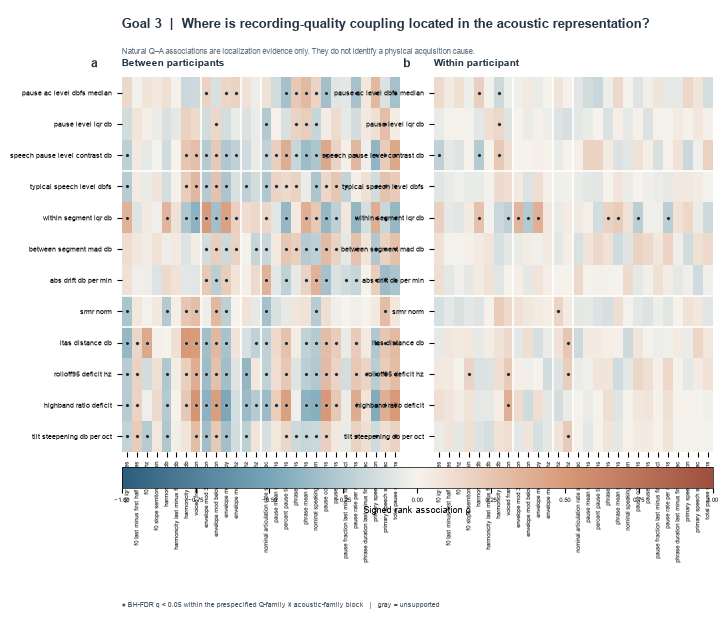

FIGURE 5: PASS


In [15]:
# ------------------------------------------------------------
# Publication geometry and palette
# ------------------------------------------------------------

MM = 1 / 25.4
DOUBLE = 183 * MM

Q_ORDER = QADD + QGAIN + QREV + QCHAN

A_ORDER_TABLE = retained_a_registry.copy()
A_ORDER_TABLE["role_order"] = (
    A_ORDER_TABLE["final_role"]
    .map({"primary": 0, "extended": 1})
    .fillna(9)
)

A_ORDER_TABLE = A_ORDER_TABLE.sort_values(
    ["acoustic_family", "role_order", "feature"]
)

A_ORDER = A_ORDER_TABLE["feature"].astype(str).tolist()

# Muted scientific diverging palette:
# negative = deep steel blue; zero = warm off-white; positive = terracotta.
qa_cmap = LinearSegmentedColormap.from_list(
    "goal3_qa",
    [
        "#2C5D7C",
        "#78A5B8",
        "#F6F3ED",
        "#D89A78",
        "#9E4F3E",
    ],
    N=256,
)

qa_cmap.set_bad("#E5E9ED")

mpl.rcParams.update({
    "font.family": ["Arial", "DejaVu Sans"],
    "font.size": 6.2,
    "axes.labelsize": 6.2,
    "axes.titlesize": 7.5,
    "xtick.labelsize": 4.6,
    "ytick.labelsize": 5.2,
    "axes.linewidth": 0.6,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",
    "figure.facecolor": "white",
    "axes.facecolor": "white",
})

def short_name(feature):
    value = str(feature)
    value = value.removeprefix("bamboo_")
    value = value.removeprefix("qadd_")
    value = value.removeprefix("qgain_")
    value = value.removeprefix("qrev_")
    value = value.removeprefix("qchan_")
    return value.replace("_", " ")

def heatmap_arrays(table):
    rho = (
        table.pivot(
            index="q_feature",
            columns="a_feature",
            values="rho",
        )
        .reindex(index=Q_ORDER, columns=A_ORDER)
    )

    sig = (
        table.pivot(
            index="q_feature",
            columns="a_feature",
            values="fdr_retained",
        )
        .reindex(index=Q_ORDER, columns=A_ORDER)
        .fillna(False)
    )

    status = (
        table.pivot(
            index="q_feature",
            columns="a_feature",
            values="status",
        )
        .reindex(index=Q_ORDER, columns=A_ORDER)
    )

    return rho, sig, status

between_rho, between_sig, between_status = heatmap_arrays(
    goal3_between
)

within_rho, within_sig, within_status = heatmap_arrays(
    goal3_within
)

fig = plt.figure(
    figsize=(DOUBLE, 164 * MM),
    facecolor="white",
)

gs = fig.add_gridspec(
    3,
    2,
    height_ratios=[0.14, 1, 0.055],
    left=0.10,
    right=0.92,
    bottom=0.24,
    top=0.98,
    wspace=0.12,
    hspace=0.10,
)

header = fig.add_subplot(gs[0, :])
header.axis("off")

header.text(
    0,
    0.72,
    "Goal 3  |  Where is recording-quality coupling located in the acoustic representation?",
    fontsize=9.1,
    fontweight="bold",
    color="#243342",
    ha="left",
    va="center",
)

header.text(
    0,
    0.20,
    (
        "Natural Q–A associations are localization evidence only. "
        "They do not identify a physical acquisition cause."
    ),
    fontsize=5.6,
    color="#607080",
    ha="left",
    va="center",
)

axes = [
    fig.add_subplot(gs[1, 0]),
    fig.add_subplot(gs[1, 1]),
]

last_im = None

for ax, rho, sig, title, letter in [
    (
        axes[0],
        between_rho,
        between_sig,
        "Between participants",
        "a",
    ),
    (
        axes[1],
        within_rho,
        within_sig,
        "Within participant",
        "b",
    ),
]:
    matrix = rho.to_numpy(dtype=float)

    last_im = ax.imshow(
        np.ma.masked_invalid(matrix),
        aspect="auto",
        interpolation="none",
        vmin=-1,
        vmax=1,
        cmap=qa_cmap,
    )

    # FDR markers.
    sig_matrix = sig.to_numpy(dtype=bool)

    yy, xx = np.where(sig_matrix)

    ax.scatter(
        xx,
        yy,
        s=7,
        marker="o",
        facecolor="#1F2933",
        edgecolor="white",
        linewidth=0.25,
        zorder=4,
    )

    ax.set_xticks(np.arange(len(A_ORDER)))
    ax.set_xticklabels(
        [short_name(feature) for feature in A_ORDER],
        rotation=90,
        ha="center",
        va="top",
    )

    ax.set_yticks(np.arange(len(Q_ORDER)))
    ax.set_yticklabels(
        [short_name(feature) for feature in Q_ORDER]
    )

    ax.set_title(
        title,
        loc="left",
        pad=8,
        fontweight="bold",
        color="#243342",
    )

    ax.text(
        -0.11,
        1.02,
        letter,
        transform=ax.transAxes,
        fontsize=8.4,
        fontweight="bold",
        ha="left",
        va="bottom",
        color="#243342",
    )

    # Thin separators between Q families.
    q_boundaries = [
        len(QADD) - 0.5,
        len(QADD) + len(QGAIN) - 0.5,
        len(QADD) + len(QGAIN) + len(QREV) - 0.5,
    ]

    for boundary in q_boundaries:
        ax.axhline(
            boundary,
            color="white",
            linewidth=1.2,
        )

    # Thin separators between acoustic families.
    a_families = [
        A_FAMILY[feature]
        for feature in A_ORDER
    ]

    for i in range(1, len(a_families)):
        if a_families[i] != a_families[i - 1]:
            ax.axvline(
                i - 0.5,
                color="white",
                linewidth=1.2,
            )

    for spine in ax.spines.values():
        spine.set_visible(False)

# Shared colorbar.
cax = fig.add_subplot(gs[2, :])
cb = fig.colorbar(
    last_im,
    cax=cax,
    orientation="horizontal",
)
cb.set_label(
    "Signed rank association ρ",
    labelpad=2,
)
cb.outline.set_linewidth(0.5)

# Add one concise visual legend note.
fig.text(
    0.10,
    0.055,
    "● BH-FDR q < 0.05 within the prespecified Q-family × acoustic-family block   |   gray = unsupported",
    fontsize=5.4,
    color="#465563",
    ha="left",
)

for ext, kwargs in [
    ("pdf", {}),
    ("svg", {}),
    ("png", {"dpi": 600}),
]:
    fig.savefig(
        FIGURES / f"Figure5_Goal3_QA_localization.{ext}",
        bbox_inches="tight",
        **kwargs,
    )

plt.show()
plt.close(fig)

atomic_write_json(
    {
        "created_utc": datetime.now(timezone.utc).isoformat(),
        "engine_version": ENGINE_VERSION,
        "source_tables": [
            "goal3_q_a_between.csv",
            "goal3_q_a_within.csv",
        ],
        "interpretation": (
            "Natural representation coupling only; "
            "no unique physical acquisition cause is identified."
        ),
    },
    FIGURES / "Figure5_Goal3_QA_localization.provenance.json",
)

print("FIGURE 5: PASS")


## 7. Freeze the fixed five-fold perturbation cross-fit

Goal 3 does **not** repeat the same digital perturbation over all 10 outer repeats.

The controlled experiment uses repeat 1 from the master split manifest as one fixed five-fold participant cross-fit.


In [8]:
goal3_crossfit = (
    split_manifest.loc[
        split_manifest["repeat"].eq(1),
        ["participant_id", "outer_fold"],
    ]
    .drop_duplicates()
    .sort_values(
        ["outer_fold", "participant_id"]
    )
    .reset_index(drop=True)
)

if len(goal3_crossfit) != EXPECTED["participants"]:
    raise RuntimeError(
        "Goal 3 fixed cross-fit does not contain 224 participants."
    )

if goal3_crossfit["participant_id"].duplicated().any():
    raise RuntimeError(
        "Goal 3 fixed cross-fit duplicates a participant."
    )

if goal3_crossfit["outer_fold"].nunique() != 5:
    raise RuntimeError(
        "Goal 3 fixed cross-fit does not contain five folds."
    )

atomic_write_csv(
    goal3_crossfit,
    TABLES / "goal3_fixed_fivefold_crossfit.csv",
)

display(
    goal3_crossfit.groupby(
        "outer_fold"
    )["participant_id"]
    .nunique()
    .rename("participants")
    .reset_index()
)

print("FIXED GOAL 3 FIVE-FOLD CROSS-FIT: FROZEN")


,outer_fold,participants
0,1,45
1,2,45
2,3,45
3,4,45
4,5,44


FIXED GOAL 3 FIVE-FOLD CROSS-FIT: FROZEN


## 8. Reuse the frozen deterministic perturbation source indices

Goal 3 must not silently re-derive chronology when Phase 0 has already frozen the deterministic source indices.

### Diagnosis

Use `goal1_diagnosis_index.csv`: one first chronological retained Bamboo recording per participant. Then restrict that already-frozen index to the same **age-complete Goal 2 diagnosis population**. This avoids the incorrect alternative of choosing the first *age-complete* recording, which could substitute a later visit.

### Severity

Use `goal1_severity_index.csv`: one first chronologically eligible ALS recording per participant after nearest-assessment matching within ≤60 days.

No source recording is selected using Q, A, model prediction, prediction error, or perturbation response.


In [9]:
# ------------------------------------------------------------
# Diagnosis source set
# Use the already-frozen Phase-0 diagnosis index, THEN restrict
# to age-complete participants.
# ------------------------------------------------------------

dx_sources = diagnosis_index.loc[
    diagnosis_index["age_at_recording_years"].notna()
].copy()

if (
    dx_sources["participant_id"].nunique()
    != EXPECTED["diagnosis_model_eligible_participants"]
):
    raise RuntimeError(
        "Goal 3 diagnosis source count differs from the frozen Goal 2 "
        "age-complete diagnosis population (expected 199)."
    )

dx_identity = diagnosis_index[
    ["participant_id", "logical_recording_id"]
].merge(
    recording_table[
        ["participant_id", "logical_recording_id"]
    ],
    on=["participant_id", "logical_recording_id"],
    how="left",
    indicator=True,
    validate="one_to_one",
)

if not dx_identity["_merge"].eq("both").all():
    raise RuntimeError(
        "At least one frozen diagnosis-index source is absent from "
        "the canonical retained recording table."
    )

dx_payload_cols = [
    column
    for column in [
        "participant_id",
        "logical_recording_id",
        "media_path",
        "media_sha256",
        "y_dx",
    ]
    if column in recording_table.columns
]

if len(dx_payload_cols) > 2:
    dx_sources = dx_sources.merge(
        recording_table[dx_payload_cols],
        on=["participant_id", "logical_recording_id"],
        how="left",
        validate="one_to_one",
        suffixes=("", "_canonical"),
    )

if "y_dx" not in dx_sources.columns:
    dx_sources["y_dx"] = dx_sources["diagnosis"].map(
        {"ALS": 1, "CONTROLS": 0}
    )

if dx_sources["y_dx"].isna().any():
    raise RuntimeError(
        "Frozen diagnosis sources contain an unrecognized diagnosis label."
    )

dx_sources = dx_sources.merge(
    goal3_crossfit,
    on="participant_id",
    how="left",
    validate="one_to_one",
)

if dx_sources["outer_fold"].isna().any():
    raise RuntimeError(
        "A diagnosis source participant lacks a Goal 3 fold."
    )

dx_source_cols = [
    column
    for column in [
        "participant_id",
        "logical_recording_id",
        "recording_date",
        "age_at_recording_years",
        "media_path",
        "media_sha256",
        "diagnosis",
        "y_dx",
        "outer_fold",
    ]
    if column in dx_sources.columns
]

goal3_dx_sources = (
    dx_sources[dx_source_cols]
    .sort_values(["outer_fold", "participant_id"])
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# Severity source set
# Reuse the already-frozen Phase-0 <=60-day severity index.
# ------------------------------------------------------------

goal3_sev_sources = severity_index.copy()

sev_identity = goal3_sev_sources[
    ["participant_id", "logical_recording_id"]
].merge(
    recording_table[
        ["participant_id", "logical_recording_id"]
    ],
    on=["participant_id", "logical_recording_id"],
    how="left",
    indicator=True,
    validate="one_to_one",
)

if not sev_identity["_merge"].eq("both").all():
    raise RuntimeError(
        "At least one frozen severity-index source is absent from "
        "the canonical retained recording table."
    )

sev_payload_cols = [
    column
    for column in [
        "participant_id",
        "logical_recording_id",
        "age_at_recording_years",
        "media_path",
        "media_sha256",
    ]
    if column in recording_table.columns
]

if len(sev_payload_cols) > 2:
    goal3_sev_sources = goal3_sev_sources.merge(
        recording_table[sev_payload_cols],
        on=["participant_id", "logical_recording_id"],
        how="left",
        validate="one_to_one",
        suffixes=("", "_canonical"),
    )

if (
    goal3_sev_sources["participant_id"].nunique()
    != EXPECTED["severity_participants_60d"]
):
    raise RuntimeError(
        "Goal 3 severity source count differs from the frozen <=60-day "
        "population (expected 145)."
    )

goal3_sev_sources = goal3_sev_sources.merge(
    goal3_crossfit,
    on="participant_id",
    how="left",
    validate="one_to_one",
)

if goal3_sev_sources["outer_fold"].isna().any():
    raise RuntimeError(
        "A severity source participant lacks a Goal 3 fold."
    )

sev_source_cols = [
    column
    for column in [
        "participant_id",
        "logical_recording_id",
        "recording_date",
        "assessment_date",
        "abs_delta_days",
        "bulbar_score",
        "age_at_recording_years",
        "media_path",
        "media_sha256",
        "outer_fold",
    ]
    if column in goal3_sev_sources.columns
]

goal3_sev_sources = (
    goal3_sev_sources[sev_source_cols]
    .sort_values(["outer_fold", "participant_id"])
    .reset_index(drop=True)
)

atomic_write_csv(
    goal3_dx_sources,
    TABLES / "goal3_diagnosis_source_manifest.csv",
)

atomic_write_csv(
    goal3_sev_sources,
    TABLES / "goal3_severity_source_manifest.csv",
)

source_summary = pd.DataFrame([
    {
        "branch": "diagnosis",
        "source_recordings": len(goal3_dx_sources),
        "participants": goal3_dx_sources["participant_id"].nunique(),
        "selection": (
            "frozen Phase-0 first chronological diagnosis index, "
            "restricted to Goal-2 age-complete participants"
        ),
    },
    {
        "branch": "severity",
        "source_recordings": len(goal3_sev_sources),
        "participants": goal3_sev_sources["participant_id"].nunique(),
        "selection": (
            "frozen Phase-0 first chronological <=60-day severity index"
        ),
    },
])

atomic_write_csv(
    source_summary,
    TABLES / "goal3_source_summary.csv",
)

display(source_summary)

print("DETERMINISTIC GOAL 3 SOURCE MANIFESTS: FROZEN")
print("Diagnosis sources:", len(goal3_dx_sources))
print("Severity sources:", len(goal3_sev_sources))


,branch,source_recordings,participants,selection
0,diagnosis,199,199,frozen Phase-0 first chronological diagnosis i...
1,severity,145,145,frozen Phase-0 first chronological <=60-day se...


DETERMINISTIC GOAL 3 SOURCE MANIFESTS: FROZEN
Diagnosis sources: 199
Severity sources: 145


## 9. Create a strictly outcome-blind signal-only dose-calibration pilot

The calibration pilot is selected from deterministic first recordings across the full retained participant set by hashing only participant/recording identity.

The exported pilot manifest deliberately excludes:

- diagnosis;
- age;
- bulbar score;
- any clinical model prediction;
- any Goal 3 model response.

This file is the only source list that the future dose-calibration stage should read.


In [10]:
# The signal-only pilot uses the frozen first-recording diagnosis index
# for all 224 participants. Clinical columns are stripped BEFORE hash ranking.

all_first_sources = diagnosis_index.copy()

pilot_columns = [
    column
    for column in [
        "participant_id",
        "logical_recording_id",
        "recording_date",
    ]
    if column in all_first_sources.columns
]

pilot = all_first_sources[pilot_columns].copy()

media_only_cols = [
    column
    for column in [
        "participant_id",
        "logical_recording_id",
        "media_path",
        "media_sha256",
    ]
    if column in recording_table.columns
]

if len(media_only_cols) > 2:
    pilot = pilot.merge(
        recording_table[media_only_cols],
        on=["participant_id", "logical_recording_id"],
        how="left",
        validate="one_to_one",
    )

pilot["hash_key"] = [
    sha256_text(
        f"{DOSE_PILOT_SALT}|{pid}|{rid}"
    )
    for pid, rid in zip(
        pilot["participant_id"],
        pilot["logical_recording_id"],
    )
]

pilot = (
    pilot.sort_values(
        ["hash_key", "logical_recording_id"],
        kind="mergesort",
    )
    .head(DOSE_PILOT_N)
    .reset_index(drop=True)
)

pilot["pilot_rank"] = np.arange(
    1,
    len(pilot) + 1,
)

prohibited_pilot_columns = {
    "diagnosis",
    "y_dx",
    "bulbar_score",
    "age_at_recording_years",
    "sex",
    "Sex",
    "prediction",
    "loss",
    "assessment_date",
    "alsfrs_total",
}

leaked = prohibited_pilot_columns & set(pilot.columns)

if leaked:
    raise RuntimeError(
        "Clinical field leaked into the signal-only calibration pilot: "
        + ", ".join(sorted(leaked))
    )

if len(pilot) != DOSE_PILOT_N:
    raise RuntimeError(
        f"Expected {DOSE_PILOT_N} signal-only pilot sources; found {len(pilot)}."
    )

if pilot["participant_id"].duplicated().any():
    raise RuntimeError(
        "Signal-only calibration pilot contains duplicate participants."
    )

atomic_write_csv(
    pilot,
    TABLES / "goal3_signal_only_dose_pilot.csv",
)

print(
    f"SIGNAL-ONLY DOSE PILOT: FROZEN ({len(pilot)} source recordings)"
)
display(pilot)


SIGNAL-ONLY DOSE PILOT: FROZEN (24 source recordings)


,participant_id,logical_recording_id,recording_date,media_path,media_sha256,hash_key,pilot_rank
0,CAPT0000114,CAPT0000114_272_1_20240806_240_PSG_BAMBOO,2024-08-06,C:\Users\musikicn\Desktop\Nevena_project\Data_...,5ba6bb45d144e069a4bacb40a91dc01e4419d67da06f67...,0028582ed31909f229a91ac749eada783c2f9220a06e18...,1
1,CAPT0000099,CAPT0000099_272_1_20240523_240_PSG_BAMBOO,2024-05-23,C:\Users\musikicn\Desktop\Nevena_project\Data_...,198bdf321133d495f663f2739c5d4f8ccc198493d78010...,00478c3829818f82f7b515bb9d4c40676a5a2865dc95f5...,2
2,CNEC012,CNEC012_1045_1_20241012_240_PSG_BAMBOO,2024-10-12,C:\Users\musikicn\Desktop\Nevena_project\Data_...,8f6b26e162d67647a9673fbd348eca0646e6b0625cfb64...,01499e9ec09f9d2f82a3e06958e7514253b619fe03fbe7...,3
3,CAPT0000170,CAPT0000170_272_1_20250527_240_PSG_BAMBOO,2025-05-27,C:\Users\musikicn\Desktop\Nevena_project\Data_...,1df2ea0d9ef91b0bed48fd76cf55275c58d394c5989686...,01b7c5c92e73f8171f09102d5d5a1d92212a2c3c4f5f22...,4
4,TIBD118,TIBD118_1003_1_20250205_240_PSG_BAMBOO,2025-02-05,C:\Users\musikicn\Desktop\Nevena_project\Data_...,3055c94d778f84ef4ac096d6ee9c1790123faeb88d7d41...,0331b35971468f7827ecd5383c0665ce249c359368e96a...,5
5,TIBD57,TIBD57_1003_1_20221019_240_PSG_BAMBOO,2022-10-19,C:\Users\musikicn\Desktop\Nevena_project\Data_...,5325e39ae8ef5105a7d581f57113c0aa85daf1550062b6...,03e065f99cfad654d51fafbad2851205cdc4315e75cb22...,6
6,CNEC027,CNEC027_1045_1_20260513_240_PSG_BAMBOO,2026-05-13,C:\Users\musikicn\Desktop\Nevena_project\Data_...,0eed0a2d2af6b8e3c2ea5bea93fcf58d5b0a8da2f2519c...,0724f386851367f5cce27c9e76b633426b6b2e3a7fc63d...,7
7,CAPT0000014,CAPT0000014_272_1_20221125_240_PSG_BAMBOO,2022-11-25,C:\Users\musikicn\Desktop\Nevena_project\Data_...,09ffdf4e40d4fe3f07cb10b8a72d54a2ae0a194d5c9c54...,093e15e347f8deb37ef55a2b754be91bf6882b1a4dc9bf...,8
8,TIBD27,TIBD27_1003_1_20220512_240_PSG_BAMBOO,2022-05-12,C:\Users\musikicn\Desktop\Nevena_project\Data_...,9a377f3daf777ce008dbe01d65edba0939b802c9456d3e...,09537ec13abf47a331d015f74d62ac985d31d01a8c0342...,9
9,TIBD99,TIBD99_1003_1_20230718_240_PSG_BAMBOO,2023-07-18,C:\Users\musikicn\Desktop\Nevena_project\Data_...,da88a01696d5b4e340d75f5ce9ca87f515fdc0ee832361...,0bff2e05ff61f17ed379e129ddd67d22c3a8c7ddab35dd...,10


## 10. Natural Q-IQR calibration targets

The future low/medium/high physical perturbation doses should, where feasible, produce median changes of approximately 0.5, 1.0, and 2.0 natural IQRs in their prespecified target Q measurement.

This table contains **signal/Q information only** and can therefore be created before any controlled clinical-model evaluation.

QDIST is intentionally absent from the natural-IQR table because natural clipping is too sparse; the controlled QDIST grid must come from the validated Paper 1 synthetic challenge contract.


In [11]:
natural_iqr_rows = []

for feature in CORE_Q:
    values = pd.to_numeric(
        natural[feature],
        errors="coerce",
    )

    values = values.loc[
        np.isfinite(values)
    ]

    if len(values) == 0:
        q25 = q75 = iqr = np.nan
    else:
        q25 = float(
            np.quantile(values, 0.25)
        )
        q75 = float(
            np.quantile(values, 0.75)
        )
        iqr = q75 - q25

    natural_iqr_rows.append({
        "q_feature": feature,
        "q_family": Q_FAMILY[feature],
        "n_available_recordings": len(values),
        "q25_raw": q25,
        "q75_raw": q75,
        "natural_iqr_raw": iqr,
        "target_low_abs_change_raw": (
            0.5 * iqr
            if np.isfinite(iqr)
            else np.nan
        ),
        "target_medium_abs_change_raw": (
            1.0 * iqr
            if np.isfinite(iqr)
            else np.nan
        ),
        "target_high_abs_change_raw": (
            2.0 * iqr
            if np.isfinite(iqr)
            else np.nan
        ),
    })

natural_q_iqr = pd.DataFrame(
    natural_iqr_rows
)

atomic_write_csv(
    natural_q_iqr,
    TABLES / "goal3_natural_q_iqr_targets.csv",
)

display(natural_q_iqr)

print("SIGNAL-ONLY NATURAL Q-IQR TARGETS: WRITTEN")


,q_feature,q_family,n_available_recordings,q25_raw,q75_raw,natural_iqr_raw,target_low_abs_change_raw,target_medium_abs_change_raw,target_high_abs_change_raw
0,qadd_pause_ac_level_dbfs_median,QADD,462,-73.684066,-58.299195,15.384870,7.692435,15.384870,30.769741
1,qadd_pause_level_iqr_db,QADD,440,3.522895,11.706668,8.183773,4.091887,8.183773,16.367546
2,qadd_speech_pause_level_contrast_db,QADD,462,30.541067,44.789643,14.248576,7.124288,14.248576,28.497152
3,qgain_typical_speech_level_dbfs,QGAIN,519,-30.713135,-25.449886,5.263249,2.631624,5.263249,10.526498
4,qgain_within_segment_iqr_db,QGAIN,519,8.046414,11.188531,3.142117,1.571058,3.142117,6.284234
5,qgain_between_segment_mad_db,QGAIN,519,1.399747,2.683383,1.283636,0.641818,1.283636,2.567272
6,qgain_abs_drift_db_per_min,QGAIN,519,1.291863,5.254722,3.962859,1.981430,3.962859,7.925718
7,qrev_srmr_norm,QREV,519,3.143047,3.880380,0.737334,0.368667,0.737334,1.474667
8,qchan_ltas_distance_db,QCHAN,519,4.146645,6.766327,2.619682,1.309841,2.619682,5.239365
9,qchan_rolloff95_deficit_hz,QCHAN,519,0.000000,560.348101,560.348101,280.174050,560.348101,1120.696201


SIGNAL-ONLY NATURAL Q-IQR TARGETS: WRITTEN


## 11. Freeze the perturbation-family design skeleton — but not the physical doses

This table freezes **what is manipulated and what must be verified**.

It deliberately does **not** invent low/medium/high physical dose values. Those values must be selected in the dedicated signal-only calibration stage using the validated Paper 1 transformation framework and the pilot above.

This is a scientific safeguard, not missing analysis.


In [12]:
perturbation_design = pd.DataFrame([
    {
        "family": "QADD",
        "transform": "stationary_colored_broadband",
        "exemplars_per_nonzero_dose": 5,
        "physical_dose_variable": "injected_SNR_dB_relative_to_baseline_strict_speech",
        "primary_target_q": "qadd_pause_ac_level_dbfs_median",
        "secondary_target_q": "qadd_speech_pause_level_contrast_db",
        "expected_primary_direction": "increase_pause_level",
        "dose_status": "UNFROZEN_SIGNAL_ONLY_CALIBRATION_REQUIRED",
    },
    {
        "family": "QADD",
        "transform": "amplitude_modulated_colored_broadband",
        "exemplars_per_nonzero_dose": 5,
        "physical_dose_variable": "injected_SNR_dB_relative_to_baseline_strict_speech",
        "primary_target_q": "qadd_pause_level_iqr_db",
        "secondary_target_q": (
            "qadd_pause_ac_level_dbfs_median | "
            "qadd_speech_pause_level_contrast_db"
        ),
        "expected_primary_direction": "increase_pause_level_variability",
        "dose_status": "UNFROZEN_SIGNAL_ONLY_CALIBRATION_REQUIRED",
    },
    {
        "family": "QGAIN",
        "transform": "uniform_level_shift",
        "exemplars_per_nonzero_dose": 1,
        "physical_dose_variable": "gain_dB",
        "primary_target_q": "qgain_typical_speech_level_dbfs",
        "secondary_target_q": "",
        "expected_primary_direction": "known_signed_shift",
        "dose_status": "UNFROZEN_SIGNAL_ONLY_CALIBRATION_REQUIRED",
    },
    {
        "family": "QGAIN",
        "transform": "smooth_time_varying_gain",
        "exemplars_per_nonzero_dose": 1,
        "physical_dose_variable": "gain_curve_amplitude_and_shape",
        "primary_target_q": "qgain_within_segment_iqr_db",
        "secondary_target_q": (
            "qgain_between_segment_mad_db | "
            "qgain_abs_drift_db_per_min"
        ),
        "expected_primary_direction": "increase_level_dynamics",
        "dose_status": "UNFROZEN_SIGNAL_ONLY_CALIBRATION_REQUIRED",
    },
    {
        "family": "QREV",
        "transform": "RIR_convolution_RMS_matched",
        "exemplars_per_nonzero_dose": 3,
        "physical_dose_variable": "prespecified_RIR_exemplar_and_smearing_level",
        "primary_target_q": "qrev_srmr_norm",
        "secondary_target_q": "",
        "expected_primary_direction": "decrease_normalized_fast_SRMR",
        "dose_status": "UNFROZEN_SIGNAL_ONLY_CALIBRATION_REQUIRED",
    },
    {
        "family": "QCHAN",
        "transform": "upper_band_restriction",
        "exemplars_per_nonzero_dose": 3,
        "physical_dose_variable": "filter_exemplar_and_cutoff_or_shape",
        "primary_target_q": "qchan_rolloff95_deficit_hz",
        "secondary_target_q": "qchan_highband_ratio_deficit",
        "expected_primary_direction": "increase_upper_band_deficits",
        "dose_status": "UNFROZEN_SIGNAL_ONLY_CALIBRATION_REQUIRED",
    },
    {
        "family": "QDIST",
        "transform": "symmetric_hard_clipping",
        "exemplars_per_nonzero_dose": 1,
        "physical_dose_variable": "validated_Paper1_hard_clip_burden",
        "primary_target_q": "qdist_hard_clipped_sample_fraction",
        "secondary_target_q": "",
        "expected_primary_direction": "increase_hard_clipped_sample_fraction",
        "dose_status": "UNFROZEN_USE_VALIDATED_PAPER1_CHALLENGE_GRID",
    },
])

atomic_write_csv(
    perturbation_design,
    TABLES / "goal3_perturbation_design_skeleton.csv",
)

display(perturbation_design)

print("PERTURBATION FAMILY / VERIFICATION CONTRACT: FROZEN")
print("PHYSICAL LOW/MEDIUM/HIGH DOSES: NOT YET FROZEN — CORRECT BY DESIGN")


,family,transform,exemplars_per_nonzero_dose,physical_dose_variable,primary_target_q,secondary_target_q,expected_primary_direction,dose_status
0,QADD,stationary_colored_broadband,5,injected_SNR_dB_relative_to_baseline_strict_sp...,qadd_pause_ac_level_dbfs_median,qadd_speech_pause_level_contrast_db,increase_pause_level,UNFROZEN_SIGNAL_ONLY_CALIBRATION_REQUIRED
1,QADD,amplitude_modulated_colored_broadband,5,injected_SNR_dB_relative_to_baseline_strict_sp...,qadd_pause_level_iqr_db,qadd_pause_ac_level_dbfs_median | qadd_speech_...,increase_pause_level_variability,UNFROZEN_SIGNAL_ONLY_CALIBRATION_REQUIRED
2,QGAIN,uniform_level_shift,1,gain_dB,qgain_typical_speech_level_dbfs,,known_signed_shift,UNFROZEN_SIGNAL_ONLY_CALIBRATION_REQUIRED
3,QGAIN,smooth_time_varying_gain,1,gain_curve_amplitude_and_shape,qgain_within_segment_iqr_db,qgain_between_segment_mad_db | qgain_abs_drift...,increase_level_dynamics,UNFROZEN_SIGNAL_ONLY_CALIBRATION_REQUIRED
4,QREV,RIR_convolution_RMS_matched,3,prespecified_RIR_exemplar_and_smearing_level,qrev_srmr_norm,,decrease_normalized_fast_SRMR,UNFROZEN_SIGNAL_ONLY_CALIBRATION_REQUIRED
5,QCHAN,upper_band_restriction,3,filter_exemplar_and_cutoff_or_shape,qchan_rolloff95_deficit_hz,qchan_highband_ratio_deficit,increase_upper_band_deficits,UNFROZEN_SIGNAL_ONLY_CALIBRATION_REQUIRED
6,QDIST,symmetric_hard_clipping,1,validated_Paper1_hard_clip_burden,qdist_hard_clipped_sample_fraction,,increase_hard_clipped_sample_fraction,UNFROZEN_USE_VALIDATED_PAPER1_CHALLENGE_GRID


PERTURBATION FAMILY / VERIFICATION CONTRACT: FROZEN
PHYSICAL LOW/MEDIUM/HIGH DOSES: NOT YET FROZEN — CORRECT BY DESIGN


## 12. Controlled-stage readiness audit

The controlled clinical perturbation stage must not run merely because Stage A passed.

It additionally requires:

1. Goal 2 FINAL success;
2. five first-repeat fold-specific frozen ridge bundles reconstructed from unmodified training participants;
3. numerical reproduction of Goal 2 repeat-1 baseline OOF predictions by those bundles;
4. full waveform perturbation + resegmentation + Q/A extraction engine;
5. signal-only low/medium/high dose calibration;
6. frozen perturbation manifest.

This notebook writes the readiness state explicitly.


In [13]:
goal2_final_success = (
    ROOT
    / "outputs"
    / "goal2"
    / "goal2_primary_v1_1"
    / "final"
    / "SUCCESS.json"
)

goal2_final_pass = False

if goal2_final_success.exists():
    try:
        payload = json.loads(
            goal2_final_success.read_text(encoding="utf-8")
        )
        goal2_final_pass = (
            payload.get("status") == "PASS"
            and payload.get("run_mode") == "FINAL"
            and int(payload.get("bootstrap_replicates", 0)) == 2000
        )
    except Exception:
        goal2_final_pass = False

readiness = {
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "engine_version": ENGINE_VERSION,
    "stageA_status": "PASS",
    "a_freeze_version": a_manifest["a_freeze_version"],
    "natural_localization_complete": True,
    "goal3_fixed_crossfit_complete": True,
    "goal3_diagnosis_sources_frozen": True,
    "goal3_severity_sources_frozen": True,
    "signal_only_pilot_frozen": True,
    "natural_q_iqr_targets_written": True,
    "perturbation_family_contract_frozen": True,
    "goal2_final_pass_detected": bool(goal2_final_pass),
    "goal2_first_repeat_model_bundles_sealed": False,
    "dose_manifest_frozen": False,
    "controlled_clinical_inference_allowed": False,
    "next_required_steps": [
        "Wait for Goal 2 FINAL PASS.",
        (
            "Seal five first-repeat fold-specific M_A / M_A+Q / "
            "M_A-resQ ridge bundles from unmodified training data and "
            "reproduce Goal 2 repeat-1 baseline OOF predictions."
        ),
        (
            "Run signal-only waveform perturbation calibration on "
            "goal3_signal_only_dose_pilot.csv and freeze low/medium/high doses."
        ),
        (
            "Only after dose freeze: run controlled held-out perturbation "
            "clinical inference."
        ),
    ],
}

atomic_write_json(
    readiness,
    OUT / "goal3_stageA_readiness.json",
)

run_manifest = {
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "engine_version": ENGINE_VERSION,
    "python_version": sys.version,
    "platform": platform.platform(),
    "input_hashes": {
        name: sha256_file(path)
        for name, path in PATHS.items()
    },
    "a_freeze_version": a_manifest["a_freeze_version"],
    "primary_A": PRIMARY_A,
    "extended_A": EXTENDED_A,
    "core_Q": CORE_Q,
    "fixed_crossfit_repeat": 1,
    "dose_pilot_n": DOSE_PILOT_N,
    "dose_pilot_salt_sha256": sha256_text(DOSE_PILOT_SALT),
    "interpretation_boundary": (
        "Natural Q-A localization is associative. Stronger direct-sensitivity "
        "language is reserved for prespecified same-source perturbations and "
        "remains transformation-specific."
    ),
}

atomic_write_json(
    run_manifest,
    OUT / "run_manifest.json",
)

required_outputs = [
    TABLES / "goal3_q_a_between.csv",
    TABLES / "goal3_q_a_within.csv",
    TABLES / "goal3_fixed_fivefold_crossfit.csv",
    TABLES / "goal3_diagnosis_source_manifest.csv",
    TABLES / "goal3_severity_source_manifest.csv",
    TABLES / "goal3_signal_only_dose_pilot.csv",
    TABLES / "goal3_natural_q_iqr_targets.csv",
    TABLES / "goal3_perturbation_design_skeleton.csv",
    FIGURES / "Figure5_Goal3_QA_localization.pdf",
]

bad = [
    str(path)
    for path in required_outputs
    if not path.exists() or path.stat().st_size == 0
]

if bad:
    raise RuntimeError(
        "Goal 3 Stage A cannot be sealed; missing/empty outputs:\n"
        + "\n".join(bad)
    )

atomic_write_json(
    {
        "created_utc": datetime.now(timezone.utc).isoformat(),
        "status": "PASS",
        "engine_version": ENGINE_VERSION,
        "natural_localization": "COMPLETE",
        "controlled_perturbation": "NOT_YET_UNBLINDED",
        "goal2_final_pass_detected": bool(goal2_final_pass),
    },
    OUT / "SUCCESS_STAGE_A.json",
)

print("\nGOAL 3 STAGE A: PASS")
print("Natural Q–A localization: COMPLETE")
print("Controlled clinical perturbation inference: CORRECTLY BLOCKED")
print("Output directory:", OUT)

if goal2_final_pass:
    print("\nGoal 2 FINAL PASS detected.")
    print("NEXT: build/seal the first-repeat five-fold Goal 2 model bundles.")
else:
    print("\nGoal 2 FINAL PASS not yet detected — expected while the final run is still running.")



GOAL 3 STAGE A: PASS
Natural Q–A localization: COMPLETE
Controlled clinical perturbation inference: CORRECTLY BLOCKED
Output directory: C:\Users\musikicn\Desktop\Nevena_project\Paper_2_Leakage\Code\outputs\goal3\stageA_v1_0

Goal 2 FINAL PASS not yet detected — expected while the final run is still running.


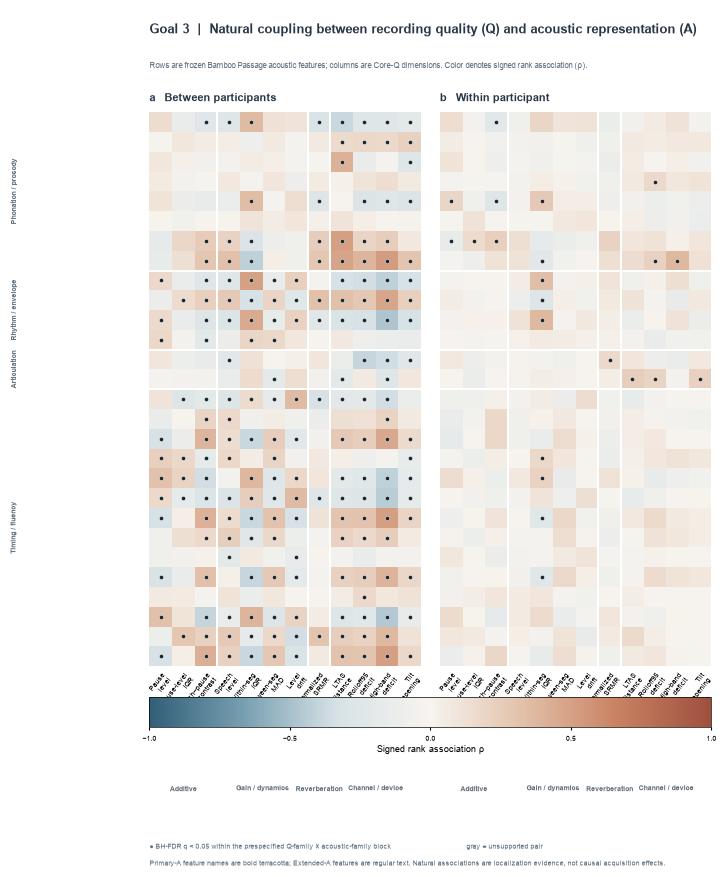

FIGURE 5 PUBLICATION v3: PASS
Saved to: C:\Users\musikicn\Desktop\Nevena_project\Paper_2_Leakage\Code\outputs\goal3\stageA_v1_0\figures


In [16]:
# ============================================================
# FIGURE 5 — GOAL 3 Q–A LOCALIZATION
# PUBLICATION VERSION — TRANSPOSED FOR READABILITY
#
# Rows    = frozen acoustic features A (28)
# Columns = Core-Q features (12)
#
# This geometry is intentionally used because 28 feature names
# cannot be displayed professionally as x-axis labels.
# ============================================================

from datetime import datetime, timezone
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Rectangle


# ============================================================
# 1. PUBLICATION GEOMETRY
# ============================================================

MM = 1 / 25.4

# Full double-column journal width, deliberately tall enough
# for 28 readable acoustic-feature rows.
FIG_W = 183 * MM
FIG_H = 225 * MM


mpl.rcParams.update({
    "font.family": ["Arial", "DejaVu Sans"],

    "font.size": 6.5,
    "axes.labelsize": 6.5,
    "axes.titlesize": 7.7,

    "xtick.labelsize": 5.0,
    "ytick.labelsize": 5.3,

    "axes.linewidth": 0.60,

    "xtick.major.size": 0,
    "ytick.major.size": 0,

    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",

    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
})


# ============================================================
# 2. ORDERING
# ============================================================

Q_ORDER = (
    QADD
    + QGAIN
    + QREV
    + QCHAN
)


# Keep frozen acoustic-family ordering.
A_ORDER_TABLE = (
    retained_a_registry
    .copy()
)

A_ORDER_TABLE["role_order"] = (
    A_ORDER_TABLE["final_role"]
    .map({
        "primary": 0,
        "extended": 1,
    })
    .fillna(9)
)


# Preserve families as blocks;
# Primary-A appears before Extended-A within each family.
A_ORDER_TABLE = (
    A_ORDER_TABLE
    .sort_values(
        [
            "acoustic_family",
            "role_order",
            "feature",
        ],
        kind="mergesort",
    )
    .reset_index(drop=True)
)


A_ORDER = (
    A_ORDER_TABLE[
        "feature"
    ]
    .astype(str)
    .tolist()
)


if len(Q_ORDER) != 12:
    raise RuntimeError(
        f"Expected 12 Core-Q numeric features; found {len(Q_ORDER)}."
    )


if len(A_ORDER) != 28:
    raise RuntimeError(
        f"Expected 28 retained A features; found {len(A_ORDER)}."
    )


# ============================================================
# 3. HUMAN-READABLE Q LABELS
# ============================================================

Q_LABELS = {
    "qadd_pause_ac_level_dbfs_median":
        "Pause\nlevel",

    "qadd_pause_level_iqr_db":
        "Pause-level\nIQR",

    "qadd_speech_pause_level_contrast_db":
        "Speech–pause\ncontrast",

    "qgain_typical_speech_level_dbfs":
        "Speech\nlevel",

    "qgain_within_segment_iqr_db":
        "Within-seg\nIQR",

    "qgain_between_segment_mad_db":
        "Between-seg\nMAD",

    "qgain_abs_drift_db_per_min":
        "Level\ndrift",

    "qrev_srmr_norm":
        "Normalized\nSRMR",

    "qchan_ltas_distance_db":
        "LTAS\ndistance",

    "qchan_rolloff95_deficit_hz":
        "Rolloff95\ndeficit",

    "qchan_highband_ratio_deficit":
        "High-band\ndeficit",

    "qchan_tilt_steepening_db_per_oct":
        "Tilt\nsteepening",
}


def pretty_q(feature):
    return Q_LABELS.get(
        feature,
        str(feature)
        .replace("qadd_", "")
        .replace("qgain_", "")
        .replace("qrev_", "")
        .replace("qchan_", "")
        .replace("_", " "),
    )


# ============================================================
# 4. HUMAN-READABLE A LABELS
#
# Known frozen Bamboo features are given concise scientific
# labels. Any unlisted feature is cleaned automatically.
# ============================================================

A_LABELS = {

    # --------------------------------------------------------
    # Timing / fluency
    # --------------------------------------------------------

    "bamboo_nominal_articulation_rate_syll_per_sec":
        "Articulation rate (syll/s)",

    "bamboo_nominal_speaking_rate_wpm":
        "Nominal speaking rate (wpm)",

    "bamboo_percent_pause_time_300ms":
        "Pause time ≥300 ms (%)",

    "bamboo_pause_count_300ms":
        "Pause count ≥300 ms",

    "bamboo_pause_mean_sec_300ms":
        "Mean pause duration",

    "bamboo_pause_cv_300ms":
        "Pause-duration CV",

    "bamboo_phrase_mean_sec_300ms":
        "Mean phrase duration",

    "bamboo_phrase_cv_300ms":
        "Phrase-duration CV",

    "bamboo_total_pause_sec_300ms":
        "Total pause duration",

    "bamboo_pause_rate_per_min_300ms":
        "Pause rate (/min)",

    "bamboo_primary_speech_support_sec":
        "Speech support duration",

    "bamboo_primary_speech_fraction":
        "Speech fraction",

    # --------------------------------------------------------
    # Prosody / phonation
    # --------------------------------------------------------

    "bamboo_f0_median_hz":
        "Median F0",

    "bamboo_f0_iqr_semitones":
        "F0 IQR (semitones)",

    "bamboo_voiced_frame_fraction":
        "Voiced-frame fraction",

    "bamboo_harmonicity_median_db":
        "Median harmonicity",

    "bamboo_harmonicity_iqr_db":
        "Harmonicity IQR",

    # --------------------------------------------------------
    # Articulation / formants
    # --------------------------------------------------------

    "bamboo_f1_iqr_hz":
        "F1 IQR",

    "bamboo_f2_iqr_hz":
        "F2 IQR",

    # --------------------------------------------------------
    # Rhythm / envelope
    # --------------------------------------------------------

    "bamboo_envelope_mod_peak_hz":
        "Envelope modulation peak",

    "bamboo_envelope_mod_3_6_fraction":
        "Envelope power 3–6 Hz",

    "bamboo_envelope_mod_below4_fraction":
        "Envelope power <4 Hz",

    "bamboo_envelope_mod_entropy":
        "Envelope modulation entropy",
}


def pretty_a(feature):

    if feature in A_LABELS:
        return A_LABELS[feature]

    text = str(feature)

    if text.startswith("bamboo_"):
        text = text[len("bamboo_"):]

    # compact common expressions
    replacements = [
        ("last_minus_first_half", "Δ second–first half"),
        ("first_half", "first half"),
        ("last_half", "second half"),
        ("nominal_", ""),
        ("_300ms", ""),
        ("_sec", " duration"),
        ("_hz", ""),
        ("_db", ""),
        ("_per_min", " /min"),
        ("_semitones", " (semitones)"),
        ("_", " "),
    ]

    for old, new in replacements:
        text = text.replace(
            old,
            new,
        )

    # Sentence-like display.
    text = " ".join(
        text.split()
    )

    if text:
        text = (
            text[0].upper()
            + text[1:]
        )

    return text


# ============================================================
# 5. A-ROLE / FAMILY LOOKUPS
# ============================================================

A_ROLE = (
    retained_a_registry
    .set_index("feature")[
        "final_role"
    ]
    .astype(str)
    .to_dict()
)


A_FAMILY_LOCAL = (
    retained_a_registry
    .set_index("feature")[
        "acoustic_family"
    ]
    .astype(str)
    .to_dict()
)


# ============================================================
# 6. MUTED SCIENTIFIC COLOR PALETTE
# ============================================================

# Negative association = steel blue
# zero                 = warm ivory
# positive association = muted terracotta

QA_CMAP = (
    LinearSegmentedColormap
    .from_list(
        "goal3_QA_publication",
        [
            "#315F78",
            "#789FB1",
            "#D7E2E6",
            "#F7F4EF",
            "#E2C0A9",
            "#C98262",
            "#9E503F",
        ],
        N=256,
    )
)


QA_CMAP.set_bad(
    "#E6EAED"
)


INK = "#273746"
INK_SOFT = "#62717E"
SEPARATOR = "#FFFFFF"
UNSUPPORTED = "#E6EAED"

PRIMARY_COLOR = "#A65345"
EXTENDED_COLOR = "#738A9A"


# ============================================================
# 7. BUILD TRANSPOSED MATRICES
#
# rows    = A
# columns = Q
# ============================================================

def make_transposed_arrays(table):

    rho = (
        table
        .pivot(
            index="a_feature",
            columns="q_feature",
            values="rho",
        )
        .reindex(
            index=A_ORDER,
            columns=Q_ORDER,
        )
    )

    sig = (
        table
        .pivot(
            index="a_feature",
            columns="q_feature",
            values="fdr_retained",
        )
        .reindex(
            index=A_ORDER,
            columns=Q_ORDER,
        )
        .fillna(False)
    )

    status = (
        table
        .pivot(
            index="a_feature",
            columns="q_feature",
            values="status",
        )
        .reindex(
            index=A_ORDER,
            columns=Q_ORDER,
        )
    )

    return (
        rho,
        sig,
        status,
    )


(
    between_rho,
    between_sig,
    between_status,
) = make_transposed_arrays(
    goal3_between
)


(
    within_rho,
    within_sig,
    within_status,
) = make_transposed_arrays(
    goal3_within
)


# ============================================================
# 8. CONTIGUOUS FAMILY BLOCKS
# ============================================================

def contiguous_blocks(values):

    output = []

    start = 0
    current = values[0]

    for i in range(
        1,
        len(values),
    ):

        if values[i] != current:

            output.append(
                (
                    current,
                    start,
                    i - 1,
                )
            )

            start = i
            current = values[i]

    output.append(
        (
            current,
            start,
            len(values) - 1,
        )
    )

    return output


a_family_sequence = [
    A_FAMILY_LOCAL[
        feature
    ]
    for feature
    in A_ORDER
]


a_family_blocks = (
    contiguous_blocks(
        a_family_sequence
    )
)


q_family_sequence = [
    Q_FAMILY[
        feature
    ]
    for feature
    in Q_ORDER
]


q_family_blocks = (
    contiguous_blocks(
        q_family_sequence
    )
)


# ============================================================
# 9. DRAWING FUNCTION
# ============================================================

def draw_QA_panel(
    ax,
    rho_df,
    sig_df,
    status_df,
    title,
    show_y_labels,
):

    matrix = (
        rho_df
        .to_numpy(
            dtype=float
        )
    )

    significance = (
        sig_df
        .to_numpy(
            dtype=bool
        )
    )

    status = (
        status_df
        .to_numpy(
            dtype=object
        )
    )

    # --------------------------------------------------------
    # Heatmap
    # --------------------------------------------------------

    image = ax.imshow(
        np.ma.masked_invalid(
            matrix
        ),
        cmap=QA_CMAP,
        vmin=-1,
        vmax=1,
        interpolation="none",
        aspect="auto",
        origin="upper",
        zorder=1,
    )

    # --------------------------------------------------------
    # Explicit gray unsupported cells
    # --------------------------------------------------------

    rows, cols = (
        status.shape
    )

    for r in range(rows):

        for c in range(cols):

            if str(
                status[r, c]
            ) != "ok":

                ax.add_patch(
                    Rectangle(
                        (
                            c - 0.5,
                            r - 0.5,
                        ),
                        1,
                        1,
                        facecolor=UNSUPPORTED,
                        edgecolor="none",
                        zorder=2,
                    )
                )

    # --------------------------------------------------------
    # BH-FDR retained cells
    # --------------------------------------------------------

    yy, xx = np.where(
        significance
    )

    ax.scatter(
        xx,
        yy,
        s=8.5,
        marker="o",
        facecolor="#18232C",
        edgecolor="white",
        linewidth=0.28,
        zorder=5,
    )

    # --------------------------------------------------------
    # Q labels — only 12 columns
    # --------------------------------------------------------

    ax.set_xticks(
        np.arange(
            len(Q_ORDER)
        )
    )

    ax.set_xticklabels(
        [
            pretty_q(feature)
            for feature
            in Q_ORDER
        ],
        rotation=52,
        ha="right",
        va="top",
        rotation_mode="anchor",
    )

    ax.tick_params(
        axis="x",
        pad=4,
        length=0,
    )

    # --------------------------------------------------------
    # A labels
    # --------------------------------------------------------

    ax.set_yticks(
        np.arange(
            len(A_ORDER)
        )
    )

    if show_y_labels:

        ax.set_yticklabels(
            [
                pretty_a(feature)
                for feature
                in A_ORDER
            ]
        )

        ax.tick_params(
            axis="y",
            pad=4,
            length=0,
        )

        # Primary-A rows are bold and subtly terracotta.
        for tick, feature in zip(
            ax.get_yticklabels(),
            A_ORDER,
        ):

            if (
                A_ROLE[
                    feature
                ]
                == "primary"
            ):

                tick.set_fontweight(
                    "bold"
                )

                tick.set_color(
                    PRIMARY_COLOR
                )

            else:

                tick.set_color(
                    INK
                )

    else:

        ax.set_yticklabels(
            []
        )

        ax.tick_params(
            axis="y",
            length=0,
        )

    # --------------------------------------------------------
    # Acoustic-family horizontal separators
    # --------------------------------------------------------

    for (
        family,
        start,
        end,
    ) in a_family_blocks[:-1]:

        ax.axhline(
            end + 0.5,
            color=SEPARATOR,
            linewidth=1.4,
            zorder=6,
        )

    # --------------------------------------------------------
    # Q-family vertical separators
    # --------------------------------------------------------

    for (
        family,
        start,
        end,
    ) in q_family_blocks[:-1]:

        ax.axvline(
            end + 0.5,
            color=SEPARATOR,
            linewidth=1.4,
            zorder=6,
        )

    # --------------------------------------------------------
    # Panel title includes letter, avoiding floating labels
    # --------------------------------------------------------

    ax.set_title(
        title,
        loc="left",
        pad=8,
        fontsize=7.7,
        fontweight="bold",
        color=INK,
    )

    # --------------------------------------------------------
    # Clean frame
    # --------------------------------------------------------

    for spine in (
        ax.spines.values()
    ):

        spine.set_visible(
            False
        )

    return image


# ============================================================
# 10. FIGURE STRUCTURE
#
# Header occupies its own row.
# Nothing is placed over either heatmap.
# ============================================================

fig = plt.figure(
    figsize=(
        FIG_W,
        FIG_H,
    ),
    facecolor="white",
)


gs = fig.add_gridspec(
    nrows=3,
    ncols=2,

    height_ratios=[
        0.13,
        1.0,
        0.055,
    ],

    width_ratios=[
        1.0,
        1.0,
    ],

    left=0.19,
    right=0.97,

    # Large bottom margin is intentional for 12 Q labels.
    bottom=0.17,
    top=0.98,

    wspace=0.07,
    hspace=0.14,
)


# ============================================================
# 11. HEADER
# ============================================================

header = fig.add_subplot(
    gs[
        0,
        :,
    ]
)

header.axis(
    "off"
)


header.text(
    0.00,
    0.72,
    (
        "Goal 3  |  Natural coupling between "
        "recording quality (Q) and acoustic representation (A)"
    ),
    ha="left",
    va="center",
    fontsize=9.2,
    fontweight="bold",
    color=INK,
)


header.text(
    0.00,
    0.22,
    (
        "Rows are frozen Bamboo Passage acoustic features; "
        "columns are Core-Q dimensions. "
        "Color denotes signed rank association (ρ)."
    ),
    ha="left",
    va="center",
    fontsize=5.7,
    color=INK_SOFT,
)


# ============================================================
# 12. HEATMAPS
# ============================================================

ax_between = fig.add_subplot(
    gs[
        1,
        0,
    ]
)


ax_within = fig.add_subplot(
    gs[
        1,
        1,
    ],
    sharey=ax_between,
)


image = draw_QA_panel(
    ax=ax_between,
    rho_df=between_rho,
    sig_df=between_sig,
    status_df=between_status,
    title="a   Between participants",
    show_y_labels=True,
)


draw_QA_panel(
    ax=ax_within,
    rho_df=within_rho,
    sig_df=within_sig,
    status_df=within_status,
    title="b   Within participant",
    show_y_labels=False,
)


# ============================================================
# 13. Q-FAMILY LABELS
#
# These are BELOW the x tick labels in their own clean region.
# They are NOT drawn over the heatmap.
# ============================================================

Q_FAMILY_PRETTY = {
    "QADD": "Additive",
    "QGAIN": "Gain / dynamics",
    "QREV": "Reverberation",
    "QCHAN": "Channel / device",
}


for ax in [
    ax_between,
    ax_within,
]:

    for (
        family,
        start,
        end,
    ) in q_family_blocks:

        center = (
            (
                start
                + end
            )
            / 2
        )

        # Convert x data coordinate to axes fraction.
        x_frac = (
            center
            + 0.5
        ) / len(
            Q_ORDER
        )

        ax.text(
            x_frac,
            -0.215,
            Q_FAMILY_PRETTY.get(
                family,
                family,
            ),
            transform=ax.transAxes,
            ha="center",
            va="top",
            fontsize=5.0,
            fontweight="bold",
            color=INK_SOFT,
            clip_on=False,
        )


# ============================================================
# 14. ACOUSTIC-FAMILY SEPARATION
#
# Family names are put only in the LEFT margin,
# away from the actual feature names.
# ============================================================

A_FAMILY_PRETTY = {
    "timing_fluency":
        "Timing / fluency",

    "rhythm_envelope":
        "Rhythm / envelope",

    "phonation_prosody":
        "Phonation / prosody",

    "segmental_articulation":
        "Articulation",

    "within_passage_change":
        "Within-passage change",
}


for (
    family,
    start,
    end,
) in a_family_blocks:

    center = (
        start
        + end
    ) / 2

    # Convert row center to axes fraction.
    y_fraction = (
        1
        - (
            center
            + 0.5
        )
        / len(
            A_ORDER
        )
    )

    # Small rotated family label safely outside feature labels.
    ax_between.text(
        -0.50,
        y_fraction,
        A_FAMILY_PRETTY.get(
            family,
            str(family)
            .replace(
                "_",
                " ",
            )
            .title(),
        ),
        transform=(
            ax_between.transAxes
        ),
        ha="center",
        va="center",
        rotation=90,
        fontsize=4.8,
        fontweight="bold",
        color=INK_SOFT,
        clip_on=False,
    )


# ============================================================
# 15. COLORBAR
# ============================================================

cbar_ax = fig.add_subplot(
    gs[
        2,
        :,
    ]
)


cbar = fig.colorbar(
    image,
    cax=cbar_ax,
    orientation="horizontal",
)


cbar.set_label(
    "Signed rank association ρ",
    labelpad=2,
)


cbar.set_ticks(
    [
        -1,
        -0.5,
        0,
        0.5,
        1,
    ]
)


cbar.outline.set_linewidth(
    0.5
)


cbar.ax.tick_params(
    labelsize=5.2,
    length=2.5,
)


# ============================================================
# 16. LEGEND / FOOTNOTE
#
# Kept below the figure, nowhere near feature names.
# ============================================================

fig.text(
    0.19,
    0.035,
    (
        "● BH-FDR q < 0.05 within the prespecified "
        "Q-family × acoustic-family block"
    ),
    fontsize=5.3,
    color=INK_SOFT,
    ha="left",
    va="center",
)


fig.text(
    0.63,
    0.035,
    (
        "gray = unsupported pair"
    ),
    fontsize=5.3,
    color=INK_SOFT,
    ha="left",
    va="center",
)


fig.text(
    0.19,
    0.016,
    (
        "Primary-A feature names are bold terracotta; "
        "Extended-A features are regular text. "
        "Natural associations are localization evidence, not causal acquisition effects."
    ),
    fontsize=5.1,
    color=INK_SOFT,
    ha="left",
    va="center",
)


# ============================================================
# 17. SAVE
# ============================================================

stem = (
    "Figure5_Goal3_QA_localization_"
    "publication_v3"
)


for (
    extension,
    kwargs,
) in [
    (
        "pdf",
        {},
    ),
    (
        "svg",
        {},
    ),
    (
        "png",
        {
            "dpi": 600,
        },
    ),
]:

    fig.savefig(
        FIGURES
        / f"{stem}.{extension}",
        bbox_inches="tight",
        **kwargs,
    )


plt.show()

plt.close(
    fig
)


atomic_write_json(
    {
        "created_utc": (
            datetime.now(
                timezone.utc
            ).isoformat()
        ),

        "engine_version":
            ENGINE_VERSION,

        "figure":
            stem,

        "geometry": (
            "A features as rows; "
            "Core-Q features as columns"
        ),

        "n_A_features":
            len(A_ORDER),

        "n_Q_features":
            len(Q_ORDER),

        "source_tables": [
            "goal3_q_a_between.csv",
            "goal3_q_a_within.csv",
        ],

        "interpretation_boundary": (
            "Natural Q-A associations localize "
            "representation coupling only."
        ),
    },

    FIGURES
    / f"{stem}.provenance.json",
)


print(
    "FIGURE 5 PUBLICATION v3: PASS"
)

print(
    "Saved to:",
    FIGURES
)